<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Análise e projeto de vigas sujeitas à flexão. Diagramas de esforços internos.

### Problema 2

Escreva as equações e desenhe os diagramas dos esforços internos para a viga indicada na figura.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P2/MSII_Au04_P2.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

In [4]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

- Carga distribuída:

\begin{equation*}
w(x) = w_0 \sin\left(\frac{\pi}{L}x\right)\quad\textrm{[N]}
\end{equation*}

- Carga resultante:

\begin{equation*}
\begin{split}
F &= \int_0^L w(x)\mathrm{d}x
= \int_0^L w_0 \sin\left(\frac{\pi}{L}x\right) \mathrm{d}x \\
&= \left[-\frac{w_0 L}{\pi} \cos\left(\frac{\pi}{L}x\right) \right]_0^L
= \frac{2 w_0 L}{\pi} \quad\textrm{[N]}
\end{split}
\end{equation*}

nota das tabelas trigonométricas: 

$$
\int \sin (ax)\mathrm{d}x = - \frac{1}{a}\cos(ax) + C
$$.

In [5]:
w0, L, x = sy.symbols('w0 L x')

w = w0*sy.sin(np.pi*x/L)
Resultante = sy.integrate(w, (x,0,L))
F = Resultante.args[0][0]
print(f' F = {F} [N]')

 F = 0.636619772367581*L*w0 [N]


- Centroide da linha de ação da carga resultante:

\begin{equation*}
\overline{x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}w(x)x~\mathrm{d}x
}{\displaystyle\int_{0}^{L} w(x)\mathrm{d}x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}
w_0 \sin\left(\frac{\pi}{L}x\right)x~\mathrm{d}x
}{2 w_0 L /\pi}
= \frac{L}{2}\quad\textrm{[m]}
\end{equation*}

In [6]:
wx = w0*sy.sin(np.pi*x/L)*x
iwx = sy.integrate(wx, (x,0,L))
print(f'integral = {iwx}')
xcent = iwx/F
print(f'xcent = {xcent}')

integral = 0.318309886183791*L**2*w0
xcent = 0.5*L


- Cálculo das reações:

\begin{equation*}
\begin{cases}
\sum F_y = 0 \\
\sum M_{A} = 0 \\
\end{cases}~\Leftrightarrow~
\begin{cases}
- \displaystyle\frac{2 w_0 L}{\pi} + R_A = 0 \\
- \displaystyle\frac{2 w_0 L}{\pi} \left(\frac{L}{2}\right) + M_A = 0 \\
\end{cases}
\Leftrightarrow~
\begin{cases}
R_A = \displaystyle\frac{2 w_0 L}{\pi} \\
M_A = \displaystyle\frac{w_0 L²}{\pi} \\
\end{cases}
\end{equation*}

In [7]:
ra, ma, x = sy.symbols('ra ma x')

EQFy = - F + ra
EQMa = - F*xcent + ma

sol = solve({EQFy,EQMa},{ra, ma})

print('\n---------')
print('Reações:')
print('---------')
RA = sol[ra]; print(f'RA = {RA} N')
MA = sol[ma]; print(f'MA = {MA} N.m')


---------
Reações:
---------
RA = 0.636619772367581*L*w0 N
MA = 0.318309886183791*L**2*w0 N.m


### Daigrama de Esforços: método das secções

#### Troço : **$~0<x<L$**

Os diagramas de esforços - esforço tranverso, $V(x)$ e momento fletor, $M(x)$:

\begin{equation*}
\begin{split}
V(x) - V(x_A) &=  - \int_0^x w(t)\mathrm{d}t V(x_A) \quad\wedge\quad V(x_A) = R_A \\
& = \displaystyle\frac{2 w_0 L}{\pi} -
\int_0^x w_0 \sin\left(\frac{\pi}{L}t\right)\mathrm{d}t \\
& = \frac{w_0 L}{\pi}\left[1+\cos\left(\frac{\pi}{L}x\right)\right]
\end{split}
\end{equation*}

\begin{equation*}
\begin{split}
M(x) - M(x_A) &=  \int_0^x v(t)\mathrm{d}t \quad\wedge\quad M(x_A) = - M_A\\
&= -\displaystyle\frac{w_0 L²}{\pi} +
\int_0^x \frac{w_0 L}{\pi}\left[1+\cos\left(\frac{\pi}{L}t\right)\right]\mathrm{d}t \\
& = \frac{w_0 L}{\pi}\left[x-L+\frac{L}{\pi}\sin\left(\frac{\pi}{L}x\right)\right]
\end{split}
\end{equation*}


In [8]:
vab, mab = sy.symbols('vab mab')

VAB_A = RA

print(w)
i1 = sy.integrate(w, (x,0,x))
vab = VAB_A - i1
VAB = vab.args[1] - vab.args[0].args[1].args[0].args[0]

print(VAB)

MAB_A = -MA # convenção de sinais

i2 = sy.integrate(vab, (x,0,x))
mab = MAB_A + i2
MAB = mab.args[0] + mab.args[1].args[0].args[0]

print('---------')
print('Troço AB:')
print('---------')
print(f'Esforço Transverso, V(x) = {VAB} [N]')
print(f'Momento fletor, M(x) = {MAB} [N.m]')

w0*sin(3.14159265358979*x/L)
0.318309886183791*L*w0*cos(3.14159265358979*x/L) + 0.31830988618379*L*w0
---------
Troço AB:
---------
Esforço Transverso, V(x) = 0.318309886183791*L*w0*cos(3.14159265358979*x/L) + 0.31830988618379*L*w0 [N]
Momento fletor, M(x) = 0.101321183642338*L**2*w0*sin(3.14159265358979*x/L) - 0.318309886183791*L**2*w0 + 0.31830988618379*L*w0*x [N.m]


#### Diagrama de Esforço Transverso

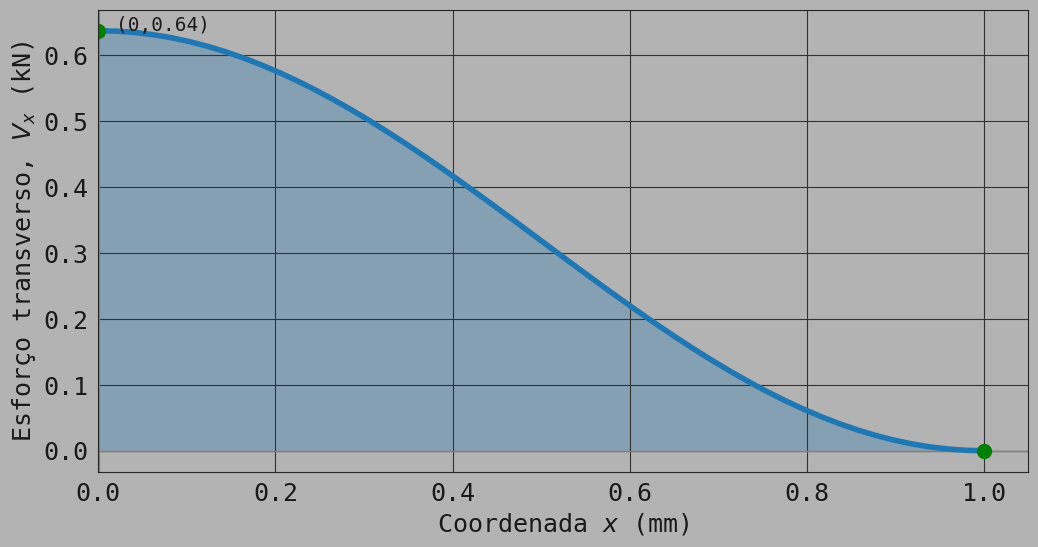

In [19]:
nL = 1
xAB = np.linspace(0,nL)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

yVAB = sy2array(VAB.subs({(L,nL),(w0,1)}),xAB)
yMAB = sy2array(MAB.subs({(L,nL),(w0,1)}),xAB) #

fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[1],yVAB[0],f'({xAB[0]:.0f},{yVAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
#plt.text(xAB[-1]*1.,yVAB[-1]*1.,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',fontsize=fz)
plt.xlim(0,nL*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,nL*1.1, 0.2),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

#### Diagrama de Momento Fletor

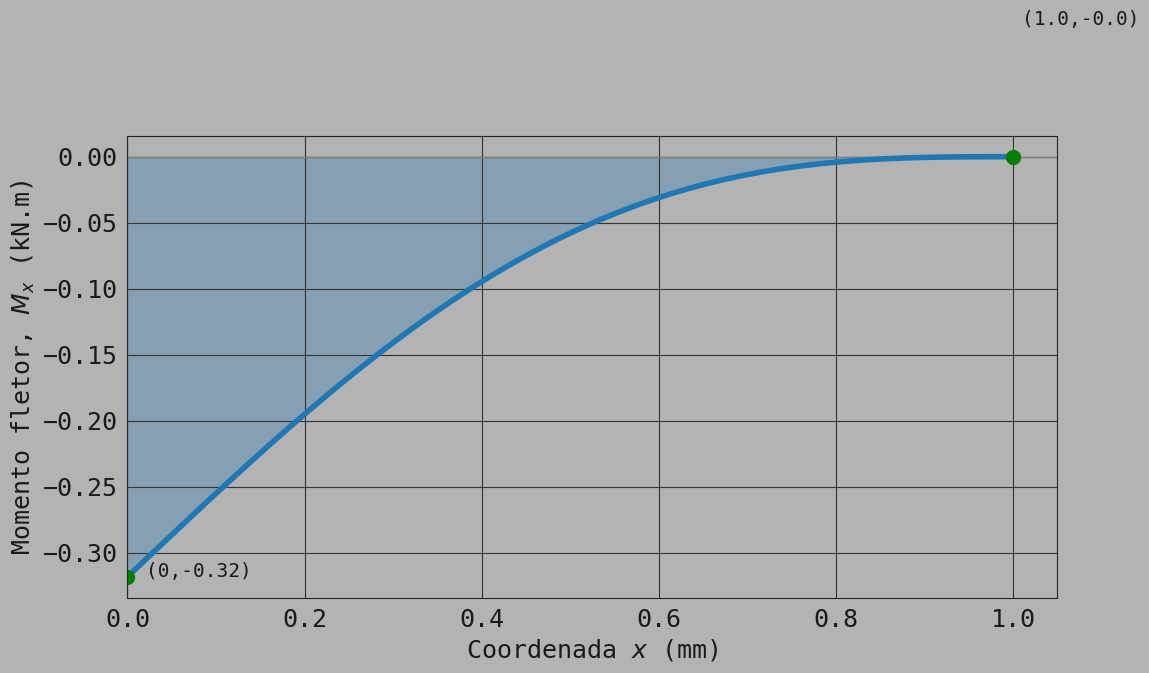

In [23]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[1],yMAB[0],f'({xAB[0]:.0f},{yMAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yMAB[-1],'go',markersize=10)
plt.text(xAB[-1]+.01,yMAB[-1]+.1,f'({xAB[-1]:.1f},{yMAB[-1]:.1f})',fontsize=fz)
plt.xlim(0,nL*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,nL*1.1, 0.2),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

### Apêndice: Relações entre carga, esforço cortante e momento fletor

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P2/FormDiagramas.png"
width="400"/>

- Esforço transverso:
  
\begin{equation*}
V_D − V_C = − \int_{x_C}^{x_D} w(x) \mathrm{d} x
\end{equation*}


ou seja, $V_D − V_C$ = −(área sob a curva de carga entre C e D)

- Momento fletos:
  
\begin{equation*}
M_D − M_C = \int_{x_C}^{x_D} V(x) \mathrm{d} x
\end{equation*}


ou seja, $M_D − M_C$ = área sob a curva de esforço cortante entre C e D

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>